In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [ ]:
!pip install transformers torch

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install wordcloud

In [ ]:
!pip install scikit-learn

In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 1 IMPORT LIBRARY
# ────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import time
import warnings
from collections import Counter
from datetime import datetime
from google.colab import files

warnings.filterwarnings('ignore')

print("=" * 60)
print("   ANALISIS SENTIMEN ULASAN GOJEK - PLAY STORE")
print("=" * 60)
print(f"  Waktu mulai : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("  Semua library berhasil diimport ")
print()

   ANALISIS SENTIMEN ULASAN GOJEK - PLAY STORE
  Waktu mulai : 2026-03-16 03:33:14
  Semua library berhasil diimport 



In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 2: TENTUKAN ID APLIKASI
# URL   : https://play.google.com/store/apps/details?id=com.gojek.app
# App ID: bagian setelah "?id=" pada URL Play Store
# ────────────────────────────────────────────────────────────────

APP_ID       = "com.gojek.app"     # ID aplikasi Gojek
APP_NAME     = "Gojek"
LANG         = "id"                # filter bahasa Indonesia
COUNTRY      = "id"                # filter negara Indonesia
TOTAL_TARGET = 5000                # jumlah ulasan yang ingin diambil
BATCH_SIZE   = 200                 # ulasan per request (maksimum 200)
OUTPUT_RAW   = "gojek_raw.csv"
OUTPUT_CLEAN = "gojek_preprocessed.csv"
OUTPUT_FINAL = "gojek_hasil_sentimen.csv"

print(f"[TAHAP 2] Konfigurasi Aplikasi")
print(f"  App ID  : {APP_ID}")
print(f"  Bahasa  : {LANG}  |  Negara : {COUNTRY}")
print(f"  Target  : {TOTAL_TARGET:,} ulasan\n")

[TAHAP 2] Konfigurasi Aplikasi
  App ID  : com.gojek.app
  Bahasa  : id  |  Negara : id
  Target  : 5,000 ulasan



In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 3: FUNGSI MENGAMBIL ULASAN
# ────────────────────────────────────────────────────────────────

from google_play_scraper import reviews, Sort

def ambil_ulasan(app_id, total, batch_size, lang, country):
    """
    Mengambil ulasan dari Google Play Store secara bertahap (batching).
    Setiap request mengambil sejumlah 'batch_size' ulasan.
    """
    semua_ulasan   = []
    token_lanjutan = None               # token untuk pagination

    for i in range(0, total, batch_size):
        try:
            hasil, token_lanjutan = reviews(
                app_id,
                lang               = lang,
                country            = country,
                sort               = Sort.NEWEST,   # terbaru lebih dulu
                count              = batch_size,
                continuation_token = token_lanjutan
            )
            semua_ulasan.extend(hasil)
            persen = min(len(semua_ulasan) / total * 100, 100)
            print(f"  Progress: {len(semua_ulasan):,}/{total:,} "
                  f"({persen:.0f}%)", end="\r")

            if not token_lanjutan:      # tidak ada halaman berikutnya
                break
            time.sleep(0.3)             # jeda untuk hindari rate limit

        except Exception as e:
            print(f"\n  [!] Error pada batch ke-{i//batch_size + 1}: {e}")
            print(f"  [!] Scraping berhenti. Terkumpul: {len(semua_ulasan):,}")
            break

    print(f"\n  Selesai! {len(semua_ulasan):,} ulasan berhasil diambil.")
    return semua_ulasan

print(f"[TAHAP 3] Fungsi ambil_ulasan() siap \n")


[TAHAP 3] Fungsi ambil_ulasan() siap 



In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 4: FUNGSI MENYIMPAN DATA
# ────────────────────────────────────────────────────────────────

def simpan_data(data_list, nama_file):
    """
    Mengubah list ulasan menjadi DataFrame, memilih kolom penting,
    lalu menyimpan ke CSV dan mengunduhnya dari Colab.
    """
    print(f"[TAHAP 4] Menyimpan data mentah...")
    df = pd.DataFrame(data_list)

    # Pilih & rename kolom yang relevan
    kolom_pilihan = {
        'userName'      : 'nama_pengguna',
        'score'         : 'rating',
        'content'       : 'ulasan',
        'at'            : 'tanggal',
        'thumbsUpCount' : 'jumlah_likes',
        'appVersion'    : 'versi_app',
    }
    kolom_ada = {k: v for k, v in kolom_pilihan.items() if k in df.columns}
    df = df[list(kolom_ada.keys())].rename(columns=kolom_ada)

    # Hapus baris dengan ulasan kosong
    df.dropna(subset=['ulasan'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Simpan ke CSV di Colab
    df.to_csv(nama_file, index=False, encoding='utf-8-sig')
    print(f"  Disimpan ke  : {nama_file}")
    print(f"  Total baris  : {len(df):,}")
    print(f"  Kolom        : {list(df.columns)}")
    return df

print(f"[TAHAP 4] Fungsi simpan_data() siap \n")

[TAHAP 4] Fungsi simpan_data() siap 



In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 4a: EKSPLORASI DATA AWAL (EDA)
# ────────────────────────────────────────────────────────────────

def eksplorasi_data(df):
    """
    Menampilkan ringkasan statistik awal dataset sebelum
    masuk ke tahap preprocessing dan analisis.
    """
    print(f"\n[TAHAP 4a] Eksplorasi Data Awal (EDA)")
    print("-" * 50)
    print(f"  Jumlah baris     : {len(df):,}")
    print(f"  Jumlah kolom     : {len(df.columns)}")
    print(f"\n  Nilai kosong per kolom:")
    print(df.isnull().sum().to_string())

    df['tanggal'] = pd.to_datetime(df['tanggal'])

    print(f"\n  Statistik Rating:")
    print(f"    Rata-rata  : {df['rating'].mean():.2f} ")
    print(f"    Median     : {df['rating'].median():.1f} ")
    print(f"    Distribusi :")
    print(df['rating'].value_counts().sort_index().to_string())

    print(f"\n  Rentang Tanggal Ulasan:")
    print(f"    Terlama  : {df['tanggal'].min().strftime('%d %b %Y')}")
    print(f"    Terbaru  : {df['tanggal'].max().strftime('%d %b %Y')}")

    df['panjang_ulasan'] = df['ulasan'].str.len()
    print(f"\n  Panjang Ulasan (karakter):")
    print(f"    Rata-rata  : {df['panjang_ulasan'].mean():.0f}")
    print(f"    Terpendek  : {df['panjang_ulasan'].min()}")
    print(f"    Terpanjang : {df['panjang_ulasan'].max()}")
    print("-" * 50)

    # Tampilkan preview tabel
    print("\n  Preview 5 baris pertama:")
    display(df[['nama_pengguna','rating','ulasan','tanggal']].head(10))
    return df

In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 5: MENJALANKAN SCRAPER
# ────────────────────────────────────────────────────────────────

print(f"[TAHAP 5] Menjalankan scraper...\n")
data_mentah = ambil_ulasan(APP_ID, TOTAL_TARGET, BATCH_SIZE, LANG, COUNTRY)

df_raw = simpan_data(data_mentah, OUTPUT_RAW)
df_raw = eksplorasi_data(df_raw)

[TAHAP 5] Menjalankan scraper...


  Selesai! 5,000 ulasan berhasil diambil.
[TAHAP 4] Menyimpan data mentah...
  Disimpan ke  : gojek_raw.csv
  Total baris  : 5,000
  Kolom        : ['nama_pengguna', 'rating', 'ulasan', 'tanggal', 'jumlah_likes', 'versi_app']

[TAHAP 4a] Eksplorasi Data Awal (EDA)
--------------------------------------------------
  Jumlah baris     : 5,000
  Jumlah kolom     : 6

  Nilai kosong per kolom:
nama_pengguna       0
rating              0
ulasan              0
tanggal             0
jumlah_likes        0
versi_app        1115

  Statistik Rating:
    Rata-rata  : 3.40 
    Median     : 5.0 
    Distribusi :
rating
1    1641
2     280
3     201
4     208
5    2670

  Rentang Tanggal Ulasan:
    Terlama  : 12 Feb 2026
    Terbaru  : 15 Mar 2026

  Panjang Ulasan (karakter):
    Rata-rata  : 75
    Terpendek  : 1
    Terpanjang : 500
--------------------------------------------------

  Preview 5 baris pertama:


,nama_pengguna,rating,ulasan,tanggal
0,DIDI Sunardi,1,tolong di parbaikin sistem penjemputannya .,2026-03-15 03:30:37
1,Susi Karmila,5,aq suka sama gojek tapi sayang di kota saya go...,2026-03-15 03:28:59
2,Agus Rachmad wijaya,1,susah cari driver,2026-03-15 03:26:01
3,Adietya Tisdam,5,selalu mudah,2026-03-15 03:25:08
4,Fai Official,1,uang refund ga dikembaliin,2026-03-15 03:21:04
5,wawan setiawan,5,mudah,2026-03-15 03:14:46
6,Ali akbar ahmad,5,Alhamdulillah,2026-03-15 03:05:36
7,Yuza Regi,5,ramah,2026-03-15 03:00:25
8,Novian Fitrianti,1,dzalim,2026-03-15 02:57:01
9,May Dian Lisanto,5,Menyenangkan,2026-03-15 02:47:19


In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 6: MEMBACA HASIL DATASET
# ────────────────────────────────────────────────────────────────

print(f"\n[TAHAP 6] Membaca ulang dataset dari file CSV...")
df = pd.read_csv(OUTPUT_RAW, encoding='utf-8-sig')
df['tanggal'] = pd.to_datetime(df['tanggal'])

print(f"  Dataset berhasil dibaca: {len(df):,} baris")
display(df.head(10))


[TAHAP 6] Membaca ulang dataset dari file CSV...
  Dataset berhasil dibaca: 5,000 baris


,nama_pengguna,rating,ulasan,tanggal,jumlah_likes,versi_app
0,DIDI Sunardi,1,tolong di parbaikin sistem penjemputannya .,2026-03-15 03:30:37,0,5.52.1
1,Susi Karmila,5,aq suka sama gojek tapi sayang di kota saya go...,2026-03-15 03:28:59,0,5.52.1
2,Agus Rachmad wijaya,1,susah cari driver,2026-03-15 03:26:01,0,5.52.1
3,Adietya Tisdam,5,selalu mudah,2026-03-15 03:25:08,0,NaN
4,Fai Official,1,uang refund ga dikembaliin,2026-03-15 03:21:04,0,NaN
5,wawan setiawan,5,mudah,2026-03-15 03:14:46,0,NaN
6,Ali akbar ahmad,5,Alhamdulillah,2026-03-15 03:05:36,0,5.52.1
7,Yuza Regi,5,ramah,2026-03-15 03:00:25,0,5.51.1
8,Novian Fitrianti,1,dzalim,2026-03-15 02:57:01,0,5.52.1
9,May Dian Lisanto,5,Menyenangkan,2026-03-15 02:47:19,0,5.52.1


In [ ]:
print("=== CEK MISSING VALUE ===")
print(df.isnull().sum())
print(f"\nTotal baris: {len(df):,}")
print(f"\nPersentase missing per kolom:")
print((df.isnull().sum() / len(df) * 100).round(2).astype(str) + " %")

=== CEK MISSING VALUE ===
nama_pengguna       0
rating              0
ulasan              0
tanggal             0
jumlah_likes        0
versi_app        1115
dtype: int64

Total baris: 5,000

Persentase missing per kolom:
nama_pengguna     0.0 %
rating            0.0 %
ulasan            0.0 %
tanggal           0.0 %
jumlah_likes      0.0 %
versi_app        22.3 %
dtype: object


In [ ]:
print("=== PENANGANAN MISSING VALUE ===")
print(f"Sebelum: {df.isnull().sum().sum()} nilai kosong\n")

# 1. Kolom 'versi_app' → isi dengan 'Tidak Diketahui'
#    karena versi app tidak kritis, cukup diisi placeholder
df['versi_app'] = df['versi_app'].fillna('Tidak Diketahui')

# 2. Kolom 'ulasan' → hapus baris jika kosong
#    karena ulasan adalah data utama yang wajib ada
df.dropna(subset=['ulasan'], inplace=True)

# 3. Kolom 'jumlah_likes' → isi dengan 0
#    karena kemungkinan memang belum ada yang like
df['jumlah_likes'] = df['jumlah_likes'].fillna(0).astype(int)

# 4. Kolom 'nama_pengguna' → isi dengan 'Anonim'
df['nama_pengguna'] = df['nama_pengguna'].fillna('Anonim')

# 5. Kolom 'rating' → hapus baris jika kosong
#    karena rating dibutuhkan untuk labeling sentimen
df.dropna(subset=['rating'], inplace=True)

df.reset_index(drop=True, inplace=True)
print(f"Sesudah: {df.isnull().sum().sum()} nilai kosong")
print(f"Total baris tersisa: {len(df):,}")
print(df.isnull().sum())

=== PENANGANAN MISSING VALUE ===
Sebelum: 1115 nilai kosong

Sesudah: 0 nilai kosong
Total baris tersisa: 5,000
nama_pengguna    0
rating           0
ulasan           0
tanggal          0
jumlah_likes     0
versi_app        0
dtype: int64


In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 6a: PREPROCESSING & PEMBERSIHAN TEKS
# ────────────────────────────────────────────────────────────────

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi tools Sastrawi (dilakukan sekali di luar fungsi agar efisien)
factory_stop     = StopWordRemoverFactory()
stopword_remover = factory_stop.create_stop_word_remover()
factory_stem     = StemmerFactory()
stemmer          = factory_stem.create_stemmer()

# Kamus normalisasi singkatan informal Bahasa Indonesia
kamus_normalisasi = {
    r'\bgk\b'    : 'tidak',    r'\bgak\b'    : 'tidak',
    r'\bnggak\b' : 'tidak',    r'\benggak\b' : 'tidak',
    r'\bga\b'    : 'tidak',    r'\bngga\b'   : 'tidak',
    r'\bbgt\b'   : 'sangat',   r'\bbanget\b' : 'sangat',
    r'\byg\b'    : 'yang',     r'\bsgt\b'    : 'sangat',
    r'\bdgn\b'   : 'dengan',   r'\bdg\b'     : 'dengan',
    r'\bkrn\b'   : 'karena',   r'\bkarna\b'  : 'karena',
    r'\bbs\b'    : 'bisa',     r'\bjg\b'     : 'juga',
    r'\bsih\b'   : '',         r'\bdeh\b'    : '',
    r'\bloh\b'   : '',         r'\bdonk\b'   : '',
    r'\bdong\b'  : '',         r'\bsj\b'     : 'saja',
    r'\baja\b'   : 'saja',     r'\bklo\b'    : 'kalau',
    r'\bkalo\b'  : 'kalau',    r'\bkmrn\b'   : 'kemarin',
    r'\bbbrp\b'  : 'beberapa', r'\bapp\b'    : 'aplikasi',
    r'\bapps\b'  : 'aplikasi', r'\bupdate\b' : 'perbarui',
    r'\bbug\b'   : 'kesalahan',r'\bcrash\b'  : 'berhenti',
    r'\berror\b' : 'eror',
}

def bersihkan_teks(teks):
    """
    Pipeline pembersihan teks 8 langkah:
    1. Case folding    → huruf kecil semua
    2. Hapus URL       → buang link
    3. Hapus non-ASCII → buang emoji & karakter asing
    4. Hapus simbol    → sisakan huruf & spasi
    5. Normalisasi     → perbaiki singkatan informal
    6. Hapus spasi     → bersihkan spasi berlebih
    7. Stopword        → hapus kata tidak bermakna
    8. Stemming        → bentuk dasar kata
    """
    if not isinstance(teks, str) or teks.strip() == "":
        return ""
    teks = teks.lower()                                    # 1
    teks = re.sub(r'http\S+|www\.\S+', '', teks)          # 2
    teks = teks.encode('ascii', 'ignore').decode('ascii')  # 3
    teks = re.sub(r'[^a-z\s]', ' ', teks)                 # 4
    for pola, pengganti in kamus_normalisasi.items():      # 5
        teks = re.sub(pola, pengganti, teks)
    teks = re.sub(r'\s+', ' ', teks).strip()               # 6
    teks = stopword_remover.remove(teks)                   # 7
    teks = stemmer.stem(teks)                              # 8
    return teks

df['ulasan_bersih'] = df['ulasan'].apply(bersihkan_teks)

# Hapus baris dengan hasil preprocessing yang kosong
sebelum = len(df)
df = df[df['ulasan_bersih'].str.strip() != ""].reset_index(drop=True)
print(f"  Selesai! {len(df):,} ulasan valid "
      f"({sebelum - len(df)} dihapus karena kosong setelah preprocessing)")

# Simpan hasil preprocessing
df.to_csv(OUTPUT_CLEAN, index=False, encoding='utf-8-sig')
print(f"  Disimpan ke: {OUTPUT_CLEAN}")

# Tampilkan perbandingan sebelum & sesudah preprocessing
print("\n  Contoh hasil preprocessing:")
contoh = df[['ulasan','ulasan_bersih']].head(10)
display(contoh)

  Selesai! 4,821 ulasan valid (179 dihapus karena kosong setelah preprocessing)
  Disimpan ke: gojek_preprocessed.csv

  Contoh hasil preprocessing:


,ulasan,ulasan_bersih
0,tolong di parbaikin sistem penjemputannya .,di parbaikin sistem jemput
1,aq suka sama gojek tapi sayang di kota saya go...,aq suka sama gojek sayang kota gojek orang dul...
2,susah cari driver,susah cari driver
3,selalu mudah,selalu mudah
4,uang refund ga dikembaliin,uang refund dikembaliin
5,mudah,mudah
6,Alhamdulillah,alhamdulillah
7,ramah,ramah
8,dzalim,dzalim
9,Menyenangkan,senang


In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 7: ANALISIS LANJUTAN
# ────────────────────────────────────────────────────────────────

# ── 7a. Labeling Sentimen (IndoBERT) ──────────────────────────
from transformers import pipeline

print("[TAHAP 7a] Memuat model IndoBERT...")
sentiment_pipeline = pipeline(
    "text-classification",
    model="mdhugol/indonesia-bert-sentiment-classification"
)

LABEL_MAP = {'LABEL_0': 'positif', 'LABEL_1': 'netral', 'LABEL_2': 'negatif'}

def tentukan_sentimen(row):
    teks = str(row['ulasan_bersih']).strip()

    # Jika teks kosong/pendek → pakai rating sebagai pendukung
    if len(teks) <= 3:
        if row['rating'] >= 4: return 'positif'
        elif row['rating'] <= 2: return 'negatif'
        else: return 'netral'

    try:
        hasil = sentiment_pipeline(teks[:512])[0]
        return LABEL_MAP.get(hasil['label'], 'netral')
    except:
        return 'netral'

df['sentimen'] = df.apply(tentukan_sentimen, axis=1)
print("Selesai! Distribusi sentimen:")
print(df['sentimen_indobert'].value_counts())

[TAHAP 7a] Memuat model IndoBERT...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Selesai! Distribusi sentimen:
sentimen
positif    2445
negatif    1990
netral      386
Name: count, dtype: int64


In [ ]:
# ── 7b. Text Mining: Frekuensi Kata ───────────────────────────

print("\n[TAHAP 7b] Text Mining: Analisis frekuensi kata...")
frekuensi_kata = {}
for sentimen in ['positif', 'negatif', 'netral']:
    subset    = df[df['sentimen'] == sentimen]['ulasan_bersih']
    semua_kata = ' '.join(subset.dropna()).split()
    semua_kata = [k for k in semua_kata if len(k) > 2]
    frekuensi_kata[sentimen] = Counter(semua_kata).most_common(20)
    top5 = [k for k,_ in frekuensi_kata[sentimen][:5]]
    print(f"  Top 5 kata {sentimen:8s}: {top5}")

# Simpan dataset final
df.to_csv(OUTPUT_FINAL, index=False, encoding='utf-8-sig')
print(f"\n  Dataset final disimpan ke: {OUTPUT_FINAL}")
display(df[['ulasan','ulasan_bersih','rating','sentimen_indobert']].head(10))


[TAHAP 7b] Text Mining: Analisis frekuensi kata...
  Top 5 kata positif : ['sangat', 'bagus', 'bantu', 'mantap', 'gojek']
  Top 5 kata negatif : ['driver', 'sangat', 'lama', 'gojek', 'nya']
  Top 5 kata netral  : ['driver', 'gojek', 'bisa', 'aplikasi', 'ada']

  Dataset final disimpan ke: gojek_hasil_sentimen.csv


,ulasan,ulasan_bersih,rating,sentimen_indobert
0,tolong di parbaikin sistem penjemputannya .,di parbaikin sistem jemput,1,netral
1,aq suka sama gojek tapi sayang di kota saya go...,aq suka sama gojek sayang kota gojek orang dul...,5,positif
2,susah cari driver,susah cari driver,1,negatif
3,selalu mudah,selalu mudah,5,positif
4,uang refund ga dikembaliin,uang refund dikembaliin,1,netral
5,mudah,mudah,5,positif
6,Alhamdulillah,alhamdulillah,5,positif
7,ramah,ramah,5,positif
8,dzalim,dzalim,1,negatif
9,Menyenangkan,senang,5,positif


In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 8: EVALUASI MODEL v
# ────────────────────────────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix

print("\n[TAHAP 8] Evaluasi Model Sentimen...")

# Sentimen dari rating sebagai ground truth
def label_dari_rating(r):
    if r >= 4:
        return 'positif'
    elif r <= 2:
        return 'negatif'
    else:
        return 'netral'

df['sentimen_rating'] = df['rating'].apply(label_dari_rating)

# Prediksi model IndoBERT
df['sentimen_indobert'] = df['sentimen']

# Evaluasi hanya data non-netral agar ground truth lebih jelas
mask = df['sentimen_rating'] != 'netral'

y_true = df.loc[mask, 'sentimen_rating']
y_pred = df.loc[mask, 'sentimen_indobert']

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=['negatif','positif'],
    target_names=['negatif','positif'],
    zero_division=0
))

conf_mat = confusion_matrix(
    y_true,
    y_pred,
    labels=['positif','negatif']
)

print("\nConfusion Matrix:")
print(conf_mat)


[TAHAP 8] Evaluasi Model Sentimen...

Classification Report:
              precision    recall  f1-score   support

     negatif       0.87      0.84      0.85      1919
     positif       0.96      0.86      0.90      2701

   micro avg       0.92      0.85      0.88      4620
   macro avg       0.91      0.85      0.88      4620
weighted avg       0.92      0.85      0.88      4620


Confusion Matrix:
[[2319  234]
 [ 109 1606]]


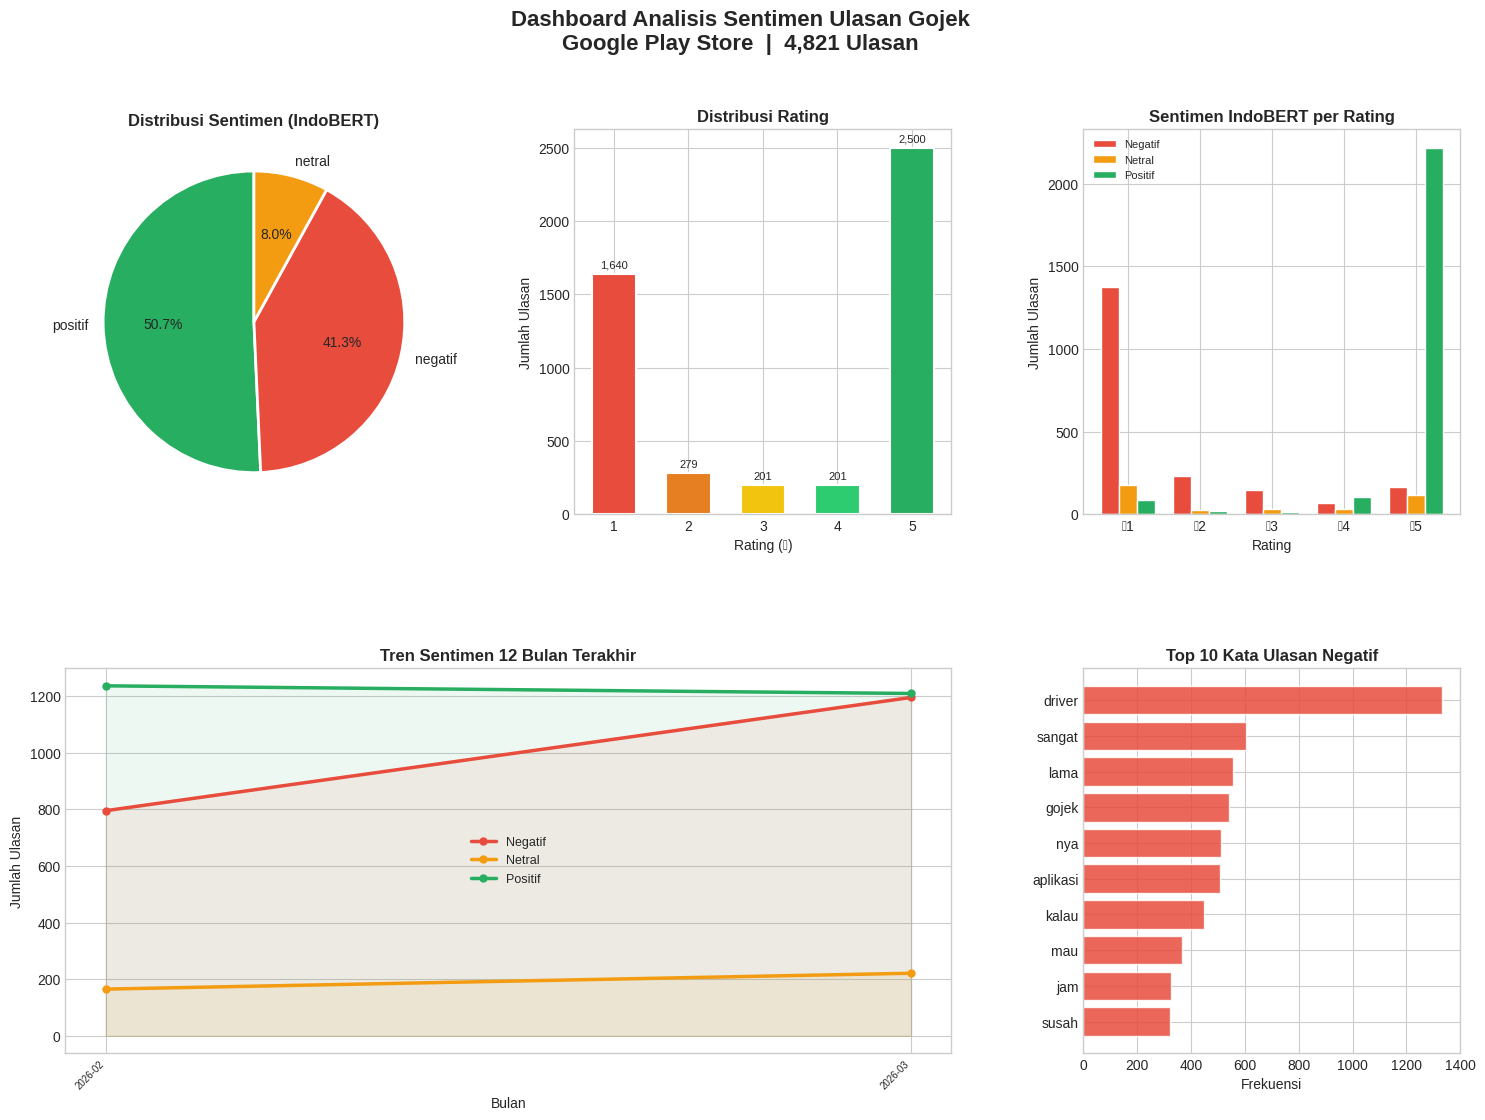

Dashboard disimpan: gojek_dashboard.png


In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 9: VISUALISASI HASIL v
# ────────────────────────────────────────────────────────────────

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

warna = {
    'positif': '#27AE60',
    'netral' : '#F39C12',
    'negatif': '#E74C3C',
}

# ── Gambar 1: Dashboard Utama ──────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'Dashboard Analisis Sentimen Ulasan {APP_NAME}\n'
             f'Google Play Store  |  {len(df):,} Ulasan',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1 – Pie chart sentimen (IndoBERT)
ax1 = fig.add_subplot(gs[0, 0])

sc = df['sentimen_indobert'].value_counts()

ax1.pie(
    sc.values,
    labels=sc.index,
    colors=[warna[s] for s in sc.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)

ax1.set_title('Distribusi Sentimen (IndoBERT)', fontweight='bold')


# Plot 2 – Bar chart rating
ax2 = fig.add_subplot(gs[0, 1])

rc = df['rating'].value_counts().sort_index()

bars = ax2.bar(
    rc.index,
    rc.values,
    color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#27AE60'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

ax2.set_title('Distribusi Rating', fontweight='bold')
ax2.set_xlabel('Rating (⭐)')
ax2.set_ylabel('Jumlah Ulasan')
ax2.set_xticks([1,2,3,4,5])

for bar, val in zip(bars, rc.values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(rc.values)*0.01,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=8
    )


# Plot 3 – Sentimen IndoBERT per Rating
ax3 = fig.add_subplot(gs[0, 2])

pivot = df.groupby(['rating','sentimen_indobert']).size().unstack(fill_value=0)

x = np.arange(len(pivot))
lebar = 0.25

for i, col in enumerate(pivot.columns):
    offset = (i - len(pivot.columns)/2 + 0.5) * lebar

    ax3.bar(
        x + offset,
        pivot[col],
        lebar,
        label=col.capitalize(),
        color=warna.get(col, 'gray'),
        edgecolor='white'
    )

ax3.set_title('Sentimen IndoBERT per Rating', fontweight='bold')
ax3.set_xlabel('Rating')
ax3.set_ylabel('Jumlah Ulasan')
ax3.set_xticks(x)
ax3.set_xticklabels([f'⭐{r}' for r in pivot.index])
ax3.legend(fontsize=8)


# Plot 4 – Tren sentimen per bulan
ax4 = fig.add_subplot(gs[1, 0:2])

df['bulan'] = df['tanggal'].dt.to_period('M')

tren = df.groupby(['bulan','sentimen_indobert']).size().unstack(fill_value=0)

tren.index = tren.index.astype(str)
tren_12 = tren.tail(12)

for col in tren_12.columns:
    ax4.plot(
        range(len(tren_12)),
        tren_12[col],
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=col.capitalize(),
        color=warna.get(col, 'gray')
    )

    ax4.fill_between(
        range(len(tren_12)),
        tren_12[col],
        alpha=0.08,
        color=warna.get(col, 'gray')
    )

ax4.set_title('Tren Sentimen 12 Bulan Terakhir', fontweight='bold')
ax4.set_xlabel('Bulan')
ax4.set_ylabel('Jumlah Ulasan')

ax4.set_xticks(range(len(tren_12)))
ax4.set_xticklabels(tren_12.index, rotation=45, ha='right', fontsize=7)

ax4.legend(fontsize=9)


# Plot 5 – Top 10 kata ulasan negatif
ax5 = fig.add_subplot(gs[1, 2])

if frekuensi_kata.get('negatif'):

    kata_neg_sorted = sorted(
        frekuensi_kata['negatif'][:10],
        key=lambda x: x[1]
    )

    ax5.barh(
        [k for k,_ in kata_neg_sorted],
        [v for _,v in kata_neg_sorted],
        color='#E74C3C',
        edgecolor='white',
        alpha=0.85
    )

ax5.set_title('Top 10 Kata Ulasan Negatif', fontweight='bold')
ax5.set_xlabel('Frekuensi')


plt.savefig('gojek_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard disimpan: gojek_dashboard.png")

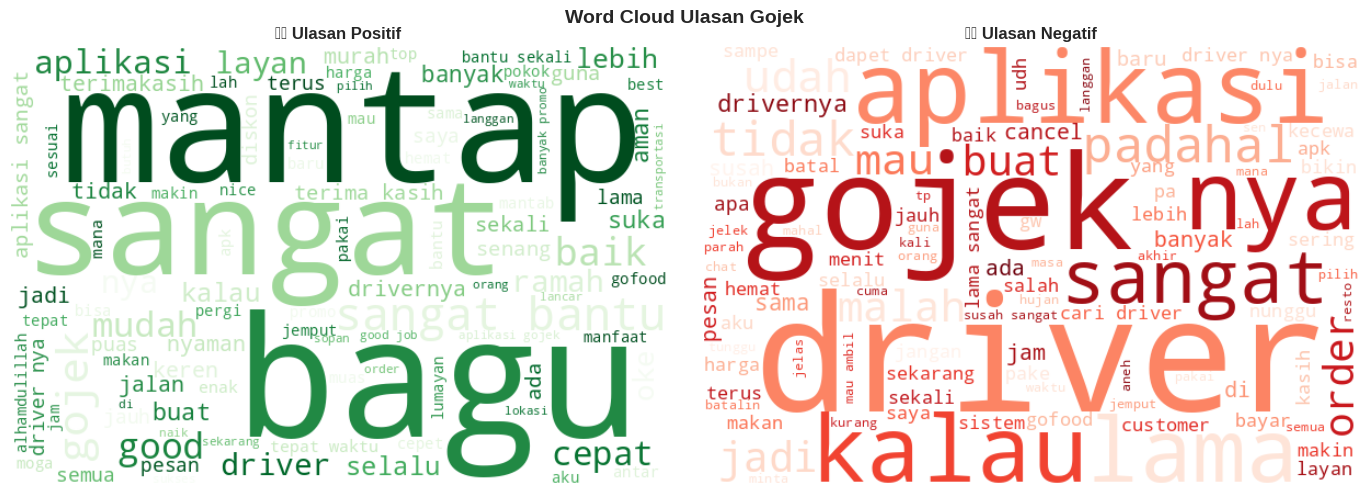

Word cloud disimpan: gojek_wordcloud.png


In [ ]:
# ── Gambar 2: Word Cloud v ───────────────────────────────────────

fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

fig2.suptitle(
    f'Word Cloud Ulasan {APP_NAME}',
    fontsize=14,
    fontweight='bold'
)

for ax, sentimen, cmap, title in [
    (axes[0], 'positif', 'Greens', '☀️ Ulasan Positif'),
    (axes[1], 'negatif', 'Reds',   '⚠️ Ulasan Negatif'),
]:

    teks_gabung = ' '.join(
        df[df['sentimen_indobert'] == sentimen]['ulasan_bersih']
        .dropna()
        .astype(str)
    )

    if teks_gabung.strip():

        wc = WordCloud(
            width=600,
            height=400,
            background_color='white',
            colormap=cmap,
            max_words=100
        ).generate(teks_gabung)

        ax.imshow(wc, interpolation='bilinear')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

plt.tight_layout()

plt.savefig(
    'gojek_wordcloud.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Word cloud disimpan: gojek_wordcloud.png")

In [ ]:
# ────────────────────────────────────────────────────────────────
# TAHAP 10: KESIMPULAN & INSIGHT v
# ────────────────────────────────────────────────────────────────

total = len(df)

# Sentimen dari IndoBERT
pos = (df['sentimen_indobert'] == 'positif').sum()
neg = (df['sentimen_indobert'] == 'negatif').sum()
net = (df['sentimen_indobert'] == 'netral').sum()

# Perbedaan antara rating dan IndoBERT
beda = (df['sentimen_rating'] != df['sentimen_indobert']).sum()

print("\n" + "=" * 60)
print("   KESIMPULAN & INSIGHT ANALISIS")
print("=" * 60)

print(f"\n  RINGKASAN DATASET")
print(f"  Total ulasan dianalisis : {total:,}")
print(f"  Rating rata-rata        : {df['rating'].mean():.2f} / 5.00")

print(f"\n  DISTRIBUSI SENTIMEN (IndoBERT)")
print(f"  Positif : {pos:,} ulasan ({pos/total*100:.1f}%)")
print(f"  Netral  : {net:,} ulasan ({net/total*100:.1f}%)")
print(f"  Negatif : {neg:,} ulasan ({neg/total*100:.1f}%)")

print(f"\n  INSIGHT OTOMATIS")

if pos/total > 0.5:
    print(f"   Mayoritas pengguna ({pos/total*100:.0f}%) memberikan ulasan positif.")
    print(f"   Secara umum aplikasi Gojek dinilai memuaskan pengguna.")
else:
    print(f"   Sebagian besar ulasan bersifat netral atau negatif.")
    print(f"   Perlu evaluasi pengalaman pengguna.")

if neg/total > 0.2:
    print(f"   {neg/total*100:.0f}% ulasan negatif — menunjukkan adanya keluhan pengguna.")

if beda/total > 0.1:
    print(f"   Terdapat perbedaan antara rating dan isi komentar.")
    print(f"   Analisis teks menggunakan NLP lebih mampu menangkap konteks ulasan.")

print(f"\n  FILE OUTPUT YANG DIHASILKAN")

print(f"   {OUTPUT_RAW:<38} Data mentah scraping")
print(f"   {OUTPUT_CLEAN:<38} Data setelah preprocessing")
print(f"   {OUTPUT_FINAL:<38} Data + label sentimen")

print(f"   gojek_dashboard.png                 Grafik dashboard")
print(f"   gojek_wordcloud.png                 Word cloud ulasan")
print(f"   gojek_confusion_matrix.png          Evaluasi model")

print(f"\n  Analisis selesai: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)


   KESIMPULAN & INSIGHT ANALISIS

  RINGKASAN DATASET
  Total ulasan dianalisis : 4,821
  Rating rata-rata        : 3.34 / 5.00

  DISTRIBUSI SENTIMEN (IndoBERT)
  Positif : 2,445 ulasan (50.7%)
  Netral  : 386 ulasan (8.0%)
  Negatif : 1,990 ulasan (41.3%)

  INSIGHT OTOMATIS
   Mayoritas pengguna (51%) memberikan ulasan positif.
   Secara umum aplikasi Gojek dinilai memuaskan pengguna.
   41% ulasan negatif — menunjukkan adanya keluhan pengguna.
   Terdapat perbedaan antara rating dan isi komentar.
   Analisis teks menggunakan NLP lebih mampu menangkap konteks ulasan.

  FILE OUTPUT YANG DIHASILKAN
   gojek_raw.csv                          Data mentah scraping
   gojek_preprocessed.csv                 Data setelah preprocessing
   gojek_hasil_sentimen.csv               Data + label sentimen
   gojek_dashboard.png                 Grafik dashboard
   gojek_wordcloud.png                 Word cloud ulasan
   gojek_confusion_matrix.png          Evaluasi model

  Analisis selesai: 2026-03